In [56]:
#!pip install pandas numpy matplotlib scikit-learn

In [57]:
import numpy as numpy
import pandas as pd
import matplotlib.pyplot as plt

In [58]:
data = pd.read_csv(r"C:\Users\soura\OneDrive\Desktop\Crypto Currency\data\raw\dataset.csv\crypto_data.csv")
data.head(5)

,Unnamed: 0,open,high,low,close,volume,marketCap,timestamp,crypto_name,date
0,0,112.900002,118.800003,107.142998,115.910004,0.0,1.288693e+09,2013-05-05T23:59:59.999Z,Bitcoin,2013-05-05
1,1,3.493130,3.692460,3.346060,3.590890,0.0,6.229819e+07,2013-05-05T23:59:59.999Z,Litecoin,2013-05-05
2,2,115.980003,124.663002,106.639999,112.300003,0.0,1.249023e+09,2013-05-06T23:59:59.999Z,Bitcoin,2013-05-06
3,3,3.594220,3.781020,3.116020,3.371250,0.0,5.859436e+07,2013-05-06T23:59:59.999Z,Litecoin,2013-05-06
4,4,112.250000,113.444000,97.699997,111.500000,0.0,1.240594e+09,2013-05-07T23:59:59.999Z,Bitcoin,2013-05-07


In [59]:
data = data.copy()

In [60]:
data.describe()

,Unnamed: 0,open,high,low,close,volume,marketCap
count,72946.000000,72946.000000,7.294600e+04,72946.000000,7.294600e+04,7.294600e+04,7.294600e+04
mean,36472.500000,870.194495,8.964124e+02,844.060640,8.712949e+02,2.207607e+09,1.474922e+10
std,21057.840705,5231.654470,5.398613e+03,5079.389387,5.235508e+03,9.617885e+09,7.501159e+10
min,0.000000,0.000000,1.022100e-10,0.000000,8.292000e-11,0.000000e+00,0.000000e+00
25%,18236.250000,0.167916,1.767999e-01,0.158630,1.682982e-01,8.320618e+06,1.860432e+08
50%,36472.500000,1.630666,1.717542e+00,1.541486,1.640219e+00,1.098756e+08,1.268539e+09
75%,54708.750000,26.070557,2.756868e+01,24.791776,2.625195e+01,6.691398e+08,5.118618e+09
max,72945.000000,67549.735581,1.621883e+05,66458.723733,6.756683e+04,3.509679e+11,1.274831e+12


In [61]:
data.shape

(72946, 10)

In [62]:
data = data[data['crypto_name'] == 'Bitcoin']

In [63]:
data['date'] = pd.to_datetime(data['date'])
data = data.sort_values('date')

In [64]:
data['returns'] = data['close'].pct_change()

In [65]:
data = data[(data['returns'] < 1) & (data['returns'] > -1)]

In [66]:
data['volatility'] = data['returns'].rolling(10).std()
data['target'] = data['volatility'].shift(-1)

In [67]:
data = data.dropna()

In [68]:
data = data.drop_duplicates()

In [69]:
data['returns'].describe()

count    3237.000000
mean        0.002510
std         0.042765
min        -0.371695
25%        -0.013844
50%         0.001841
75%         0.019188
max         0.429680
Name: returns, dtype: float64

In [70]:
data['volatility'].describe()

count    3237.000000
mean        0.036036
std         0.022582
min         0.002147
25%         0.020532
50%         0.031704
75%         0.045824
max         0.161070
Name: volatility, dtype: float64

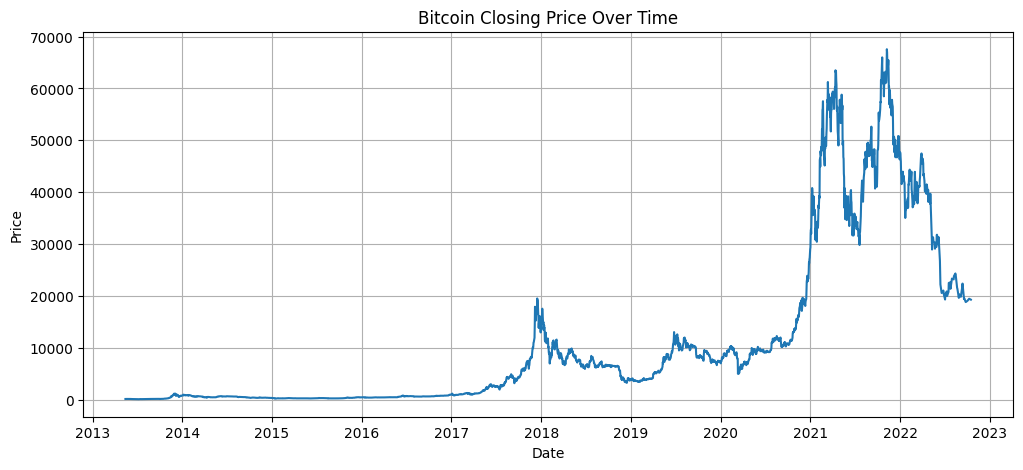

In [71]:
#price over time 
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(data['date'], data['close'])
plt.title("Bitcoin Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)
plt.show()

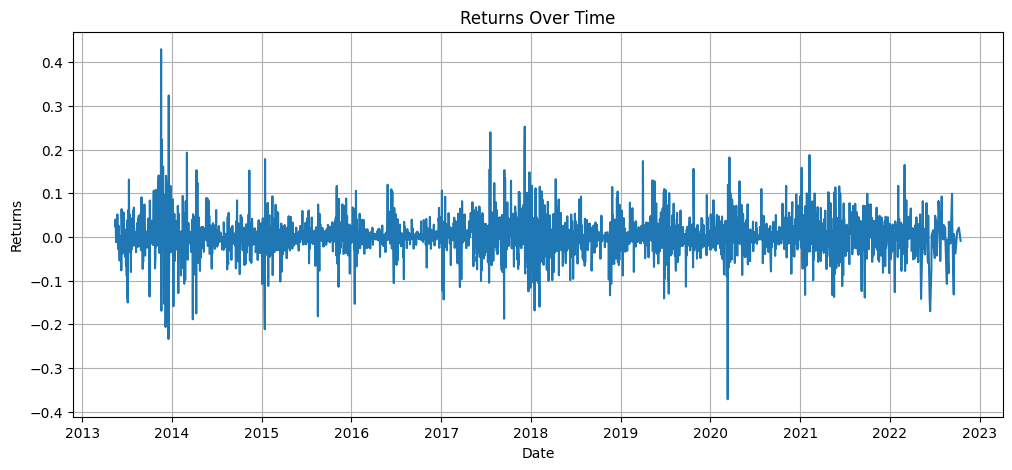

In [72]:
#Returns Over time 
plt.figure(figsize=(12,5))
plt.plot(data['date'], data['returns'])
plt.title("Returns Over Time")
plt.xlabel("Date")
plt.ylabel("Returns")
plt.grid(True)
plt.show()

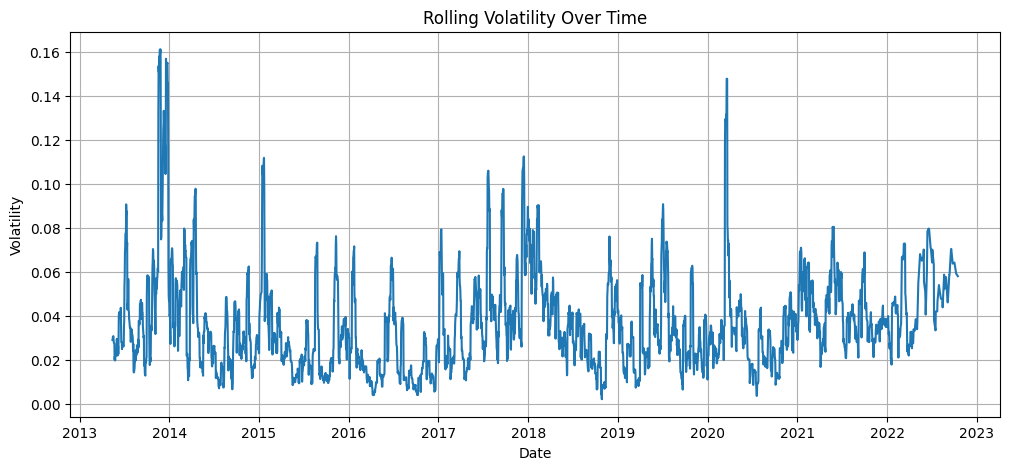

In [73]:
#volatility over time 
plt.figure(figsize=(12,5))
plt.plot(data['date'], data['volatility'])
plt.title("Rolling Volatility Over Time")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.grid(True)
plt.show()

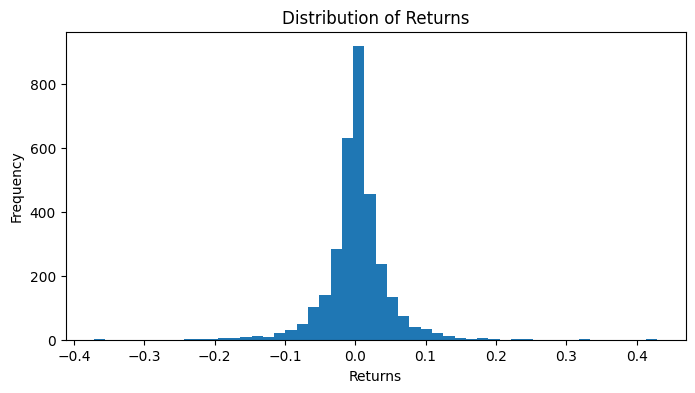

In [74]:
plt.figure(figsize=(8,4))
plt.hist(data['returns'], bins=50)
plt.title("Distribution of Returns")
plt.xlabel("Returns")
plt.ylabel("Frequency")
plt.show()

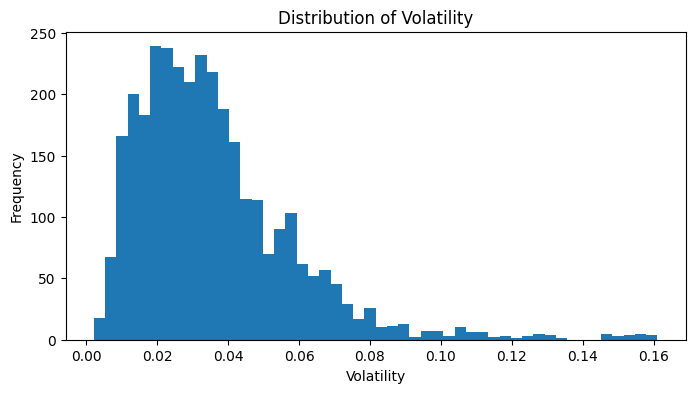

In [75]:
plt.figure(figsize=(8,4))
plt.hist(data['volatility'], bins=50)
plt.title("Distribution of Volatility")
plt.xlabel("Volatility")
plt.ylabel("Frequency")
plt.show()

In [76]:
#!pip install seaborn

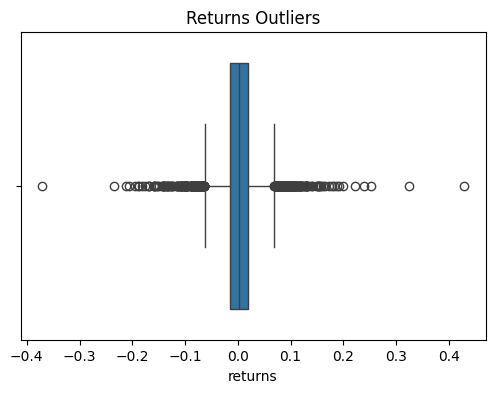

In [77]:
import seaborn as sns

plt.figure(figsize=(6,4))
sns.boxplot(x=data['returns'])
plt.title("Returns Outliers")
plt.show()

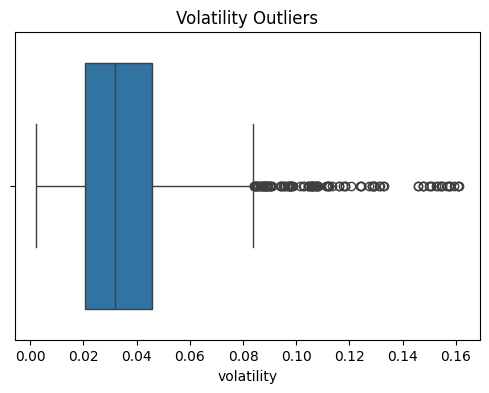

In [78]:
plt.figure(figsize=(6,4))
sns.boxplot(x=data['volatility'])
plt.title("Volatility Outliers")
plt.show()

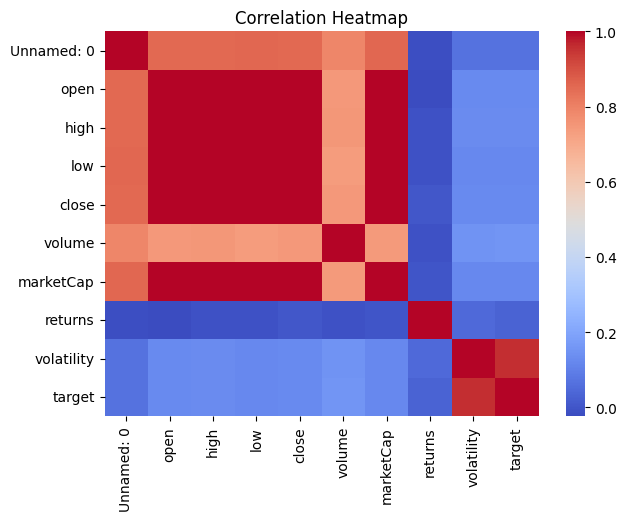

In [79]:
plt.figure(figsize=(7,5))
sns.heatmap(data.corr(numeric_only=True), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

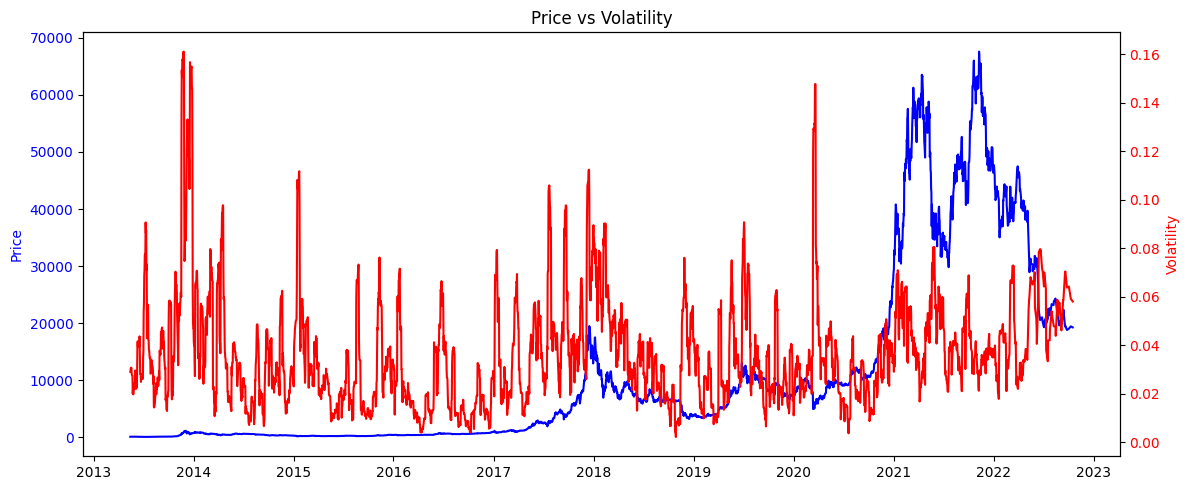

In [80]:
fig, ax1 = plt.subplots(figsize=(12,5))

# --- Price Plot (Blue) ---
color1 = 'blue' 
ax1.plot(data['date'], data['close'], color=color1)
ax1.set_ylabel('Price', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)

# --- Volatility Plot (Red) ---
ax2 = ax1.twinx()
color2 = 'red' 
ax2.plot(data['date'], data['volatility'], color=color2)
ax2.set_ylabel('Volatility', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

plt.title("Price vs Volatility")
fig.tight_layout()
plt.show()


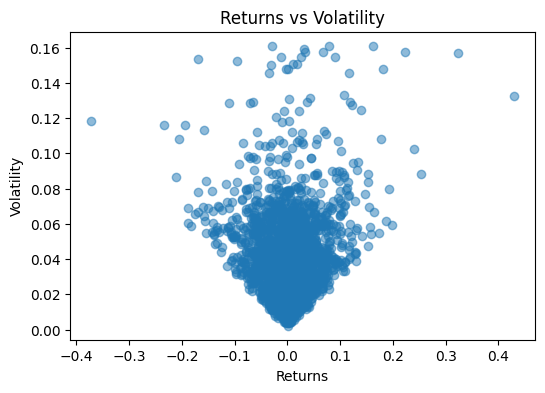

In [81]:
plt.figure(figsize=(6,4))
plt.scatter(data['returns'], data['volatility'], alpha=0.5)
plt.title("Returns vs Volatility")
plt.xlabel("Returns")
plt.ylabel("Volatility")
plt.show()

In [82]:
data.to_csv("../data/processed/processed_data.csv", index=False)

In [83]:
data

,Unnamed: 0,open,high,low,close,volume,marketCap,timestamp,crypto_name,date,returns,volatility,target
20,20,111.400002,115.809998,103.500000,114.220001,0.000000e+00,1.274624e+09,2013-05-15T23:59:59.999Z,Bitcoin,2013-05-15,0.024395,0.029055,0.029550
22,22,114.220001,118.760002,112.199997,118.760002,0.000000e+00,1.325727e+09,2013-05-16T23:59:59.999Z,Bitcoin,2013-05-16,0.039748,0.029550,0.030535
24,24,118.209999,125.300003,116.570999,123.014999,0.000000e+00,1.373724e+09,2013-05-17T23:59:59.999Z,Bitcoin,2013-05-17,0.035829,0.030535,0.030447
27,27,123.500000,125.250000,122.300003,123.498001,0.000000e+00,1.379575e+09,2013-05-18T23:59:59.999Z,Bitcoin,2013-05-18,0.003926,0.030447,0.030740
29,29,123.210999,124.500000,119.570999,121.989998,0.000000e+00,1.363205e+09,2013-05-19T23:59:59.999Z,Bitcoin,2013-05-19,-0.012211,0.030740,0.028677
...,...,...,...,...,...,...,...,...,...,...,...,...,...
72621,72621,19418.571422,19639.479733,18390.318710,19544.129250,4.017700e+10,3.743735e+11,2022-09-19T23:59:59.999Z,Bitcoin,2022-09-19,0.006417,0.070418,0.063726
72692,72692,18936.311515,19134.733194,18696.468304,18802.097976,2.335997e+10,3.602593e+11,2022-09-25T23:59:59.999Z,Bitcoin,2022-09-25,-0.037967,0.063726,0.064190
72752,72752,19311.848708,19370.309281,18970.620583,19044.107272,2.076596e+10,3.650248e+11,2022-10-02T23:59:59.999Z,Bitcoin,2022-10-02,0.012871,0.064190,0.059184
72815,72815,19417.479411,19542.538654,19349.258953,19446.426194,1.683726e+10,3.728768e+11,2022-10-09T23:59:59.999Z,Bitcoin,2022-10-09,0.021126,0.059184,0.058001
